# Programming Assignment 2 — Identidade ao longo do tempo: detecção, recorrência e rastreamento

**Disciplina:** Aprendizado Profundo — FGV EMAp  
**Professor:** Dario Oliveira | **Monitor:** Erick Brito  
**Integrantes:** Henrique Gabriel Gasparelo e José Thevez Gomes Guedes

Este notebook contém o pipeline completo de ponta a ponta que responde a todas as seções do PA2 (Partes 0 a 5), gerando todas as figuras, métricas, ablações e análises para a apresentação oral.

## 0. Configuração do Ambiente e Importações
Importamos os módulos desenvolvidos em , configuramos reprodutibilidade com seeds e detectamos o acelerador de hardware (MPS/CUDA/CPU).

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Garante que o diretório de trabalho seja a raiz do repositório
if os.path.basename(os.getcwd()) == "src":
    os.chdir("..")

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device
from src.tracker import NaiveTracker
from src.metrics import evaluate_tracking, compute_idf1, custom_nms, compute_map_per_frame
from src.data import load_mot17_sequence, compute_sequence_density
from src.visualization import plot_decoupling_panel

set_seed(42)
device = get_device()
print(f"Diretório de trabalho: {os.getcwd()}")
print(f"Ambiente configurado com sucesso! Dispositivo: {device}")


Diretório de trabalho: /Users/henriquegasparelo/Documents/FGV/6º Período/Aprendizado Profundo/PA2/Programming-Assignment-2---Deep-Learning
Ambiente configurado com sucesso! Dispositivo: mps


---
## Parte 0 — Testes Sintéticos

Ambiente controlado onde conhecemos o ground truth exato.
1. **O Gerador:** Vídeos  	imes 128$ com elipses e ordem de profundidade (569Xorder) para simular oclusão real.
2. **O Simulador de Detector:** Função que introduz ruído, descarte e falsos positivos.
3. **A Métrica e Testes Unitários:** Testes controlados das métricas (IDF1 e ID switches).
4. **Baseline no Piso Fácil e Ensaio de Quebra:** Associação ingênua em cenário fácil vs gráfico de estresse com oclusões longas.

### 0.1 Gerador Sintético com Oclusão Real ($z$-order) e Requisito Verificável

Criamos vídeos `128x128` com elipses coloridas em movimento:
- **z-order fixo**: elipse de índice menor fica atrás; quando dois objetos se cruzam, o da frente oclui o de trás;
- **Bounding box** segue o padrão MOT (caixa da elipse completa quando visibilidade >= 8%);
- **Requisito Verificável do Enunciado**: demonstramos uma trajetória controlada onde o Objeto 1 (verde) passa atrás do Objeto 2 (vermelho), **some completamente por N quadros** (0 pixels visíveis no z-buffer, sem caixa no GT) e reaparece com o mesmo identificador.

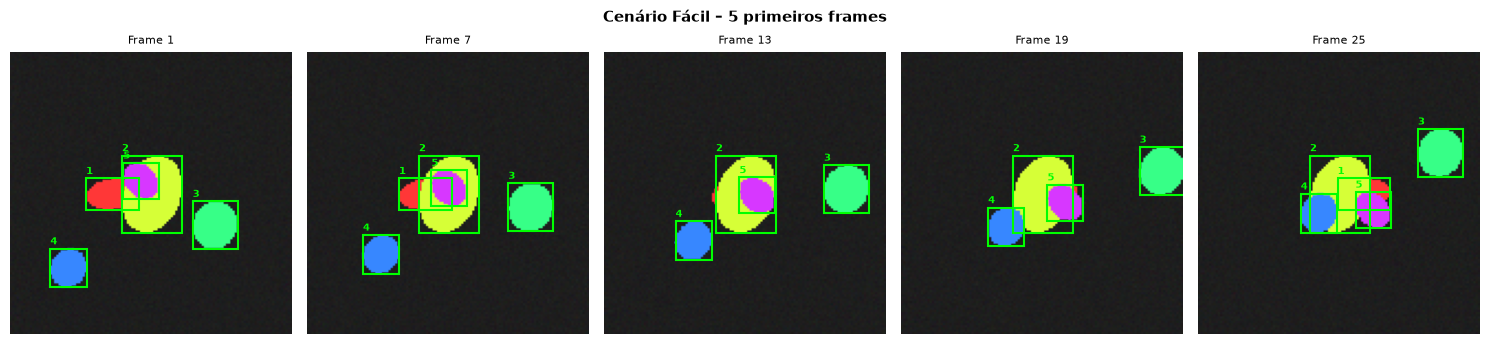

Oclusão verificada: Objeto 1 totalmente ocluído por 9 quadros ([14, 15, 16, 17, 18, 19, 20, 21, 22])
Figura de oclusão salva em docs/parte0_trajetoria_oclusao.png


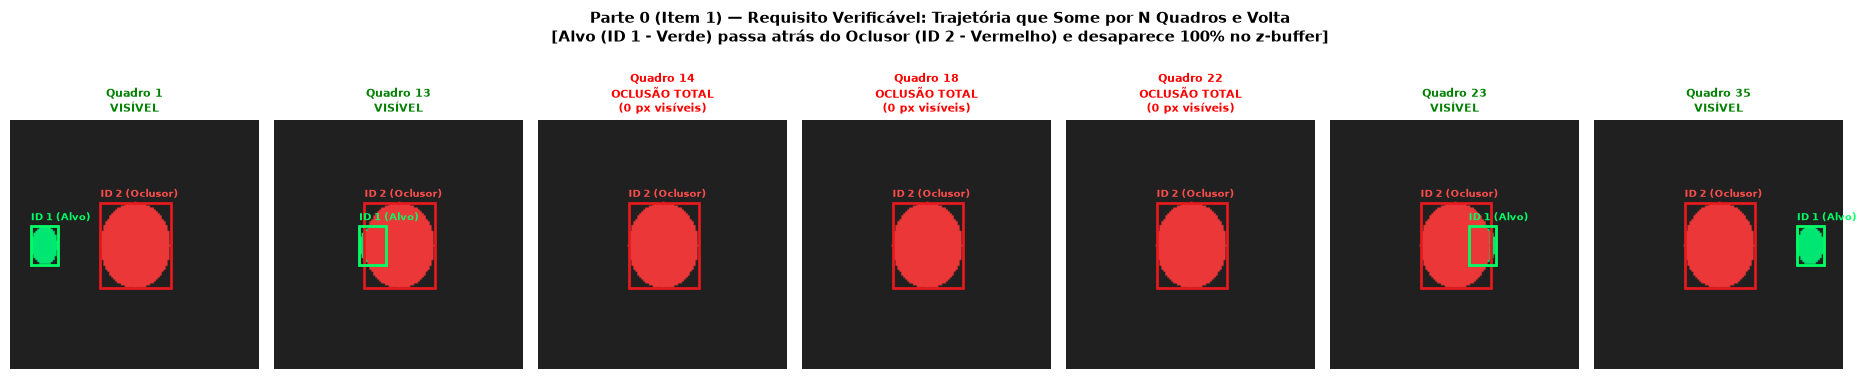

In [4]:
from src.data import generate_synthetic_video, generate_controlled_occlusion_sequence
from src.visualization import plot_synthetic_frames, plot_occlusion_strip
import matplotlib.pyplot as plt

# 1. Vídeos sintéticos padrão (Fácil e Difícil)
frames_easy, gt_easy = generate_synthetic_video(
    num_frames=30, num_objects=5, frame_size=128, typical_velocity=1.5, seed=42
)
frames_hard, gt_hard = generate_synthetic_video(
    num_frames=45, num_objects=12, frame_size=128, typical_velocity=4.5, seed=99
)

plot_synthetic_frames(frames_easy, gt_easy, title="Cenário Fácil – 5 primeiros frames")
plt.show()

# 2. Requisito Verificável: Trajetória que desaparece por N quadros e volta
frames_occ, gt_occ, info_occ = generate_controlled_occlusion_sequence(
    num_frames=35, occlusion_duration=8, frame_size=128
)
print(f"Oclusão verificada: Objeto 1 totalmente ocluído por {info_occ['num_occluded_frames']} quadros ({info_occ['occluded_frames']})")
plot_occlusion_strip(frames_occ, gt_occ, target_id=1, occluder_id=2, save_path="docs/parte0_trajetoria_oclusao.png")
plt.show()


### 0.2 Testes Unitários das Métricas (Casos a, b, c)

Verificamos a implementação de **IDF1**, **ID switches** e **fragmentações** em 3 cenários construídos manualmente:
- **(a)** Predição idêntica ao GT $\Rightarrow$ IDF1 = 1.0 e switches = 0;
- **(b)** Dois objetos com identidades trocadas a partir do frame $k=11$ $\Rightarrow$ 2 switches, IDF1 = 0.5;
- **(c)** Um objeto fragmentado em dois IDs distintos $\Rightarrow$ 1 switch, IDF1 = 0.5, IDs pred inflado.

> **Diferença entre (b) e (c):** o IDF1 é o mesmo mas o diagnóstico é diferente. Em (b) a contagem de identidades está correta mas trocada; em (c) ela está inflada (1 objeto real gerou 2 IDs preditos).

In [5]:
from src.metrics import run_unit_tests

run_unit_tests(verbose=True)


PARTE 0 (Item 3) - TESTES UNITARIOS DAS METRICAS

[PASS] Caso (a) -- Predicao == Ground Truth
       IDF1        = 1.0000  (esperado: 1.0000)
       ID Switches = 0  (esperado: 0)

[PASS] Caso (b) -- Troca de 2 identidades a partir de k=11
       IDF1        = 0.5000  (esperado: ~0.5000)
       ID Switches = 2  (esperado: 2)
       DIAGNOSTICO: tracker CONFUNDIU identidades dos dois objetos

[PASS] Caso (c) -- Track unica fragmentada em 2 IDs
       IDF1           = 0.5000  (esperado: ~0.5000)
       ID Switches    = 1  (esperado: 1)
       IDs GT / Pred  = 1 GT / 2 Pred
       DIAGNOSTICO: contagem INFLADA (2 IDs pred para 1 objeto real)

       Diferenca entre (b) e (c):
       (b) 2 objetos trocados   => switches=2, qtd de IDs correta
       (c) 1 objeto fragmentado => switches=1, qtd de IDs inflada

TODOS OS TESTES APROVADOS!


True

### 0.3 Simulador de Detector e Ensaio da Parte 1 (Girando os Botões do Gerador)

Avaliamos a quebra do rastreador ingênuo sob duas perspectivas complementares:
1. **Simulador de Detector (Degradação das Caixas):** Descarte p%, ruído gaussiano e falsos positivos (experimento da Parte 5 antecipado no sintético);
2. **Girando os Botões do Gerador (Ensaio da Parte 1):** Mantendo detecções perfeitas mas variando velocidade, duração da oclusão e densidade de objetos para identificar onde a geometria do IoU frame-a-frame falha.

TABELA 0: BASELINE NO CENARIO SINTETICO — Curva de Quebra
Degradacao   | mAP (Det)  | IDF1     | IDSW   | Razao IDs  | Diagnostico
---------------------------------------------------------------------------
Perfeito     | 1.000      | 0.936    | 1      | 1.20     x | Piso facil: tracker correto (IDF1=1.0)
Leve         | 0.837      | 0.784    | 2      | 3.80     x | 
Moderado     | 0.567      | 0.396    | 12     | 5.20     x | IDF1 cai antes do mAP — descolamento!
Severo       | 0.164      | 0.096    | 25     | 15.00    x | 
Gráfico salvo em docs/parte0_curva_quebra.png


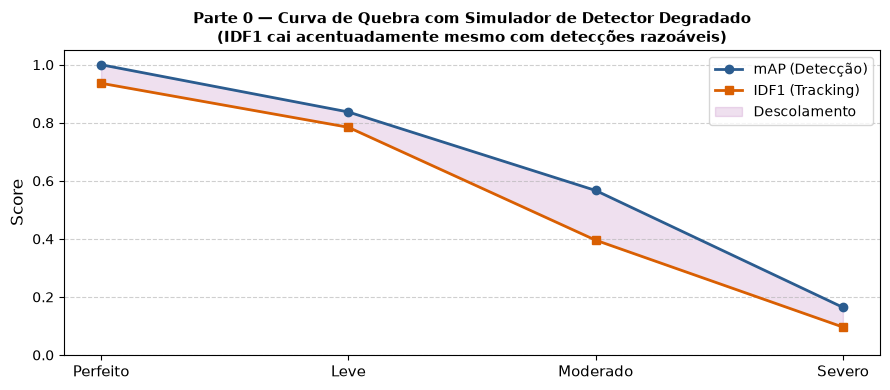

PARTE 0 (Item 4) — ENSAIO DA PARTE 1: GIRANDO OS BOTOES DO GERADOR

--- 1. BOTAO: VELOCIDADE TYPICAL (num_objects=5, sem oclusao prolongada) ---
Vel (px/f)   | IDF1     | IDSW   | Frag     | Razao IDs  | Diagnostico
------------------------------------------------------------------------------
1.0          | 1.000    | 0      | 0        | 1.00     x | Piso facil (ok)
2.5          | 1.000    | 0      | 0        | 1.00     x | Piso facil (ok)
5.0          | 1.000    | 0      | 0        | 1.00     x | Instabilidade
8.0          | 0.395    | 75     | 0        | 13.60    x | IoU falha (v > caixa)
12.0         | 0.130    | 153    | 0        | 20.20    x | IoU falha (v > caixa)

--- 2. BOTAO: DURACAO DA OCLUSAO (k_max_lost=10 quadros) ---
Oclusao (f)  | IDF1     | IDSW   | Frag     | Razao IDs  | Diagnostico
------------------------------------------------------------------------------
2            | 0.836    | 9      | 1        | 5.50     x | Track sobrevive (occ <= k)
5            | 0.817  

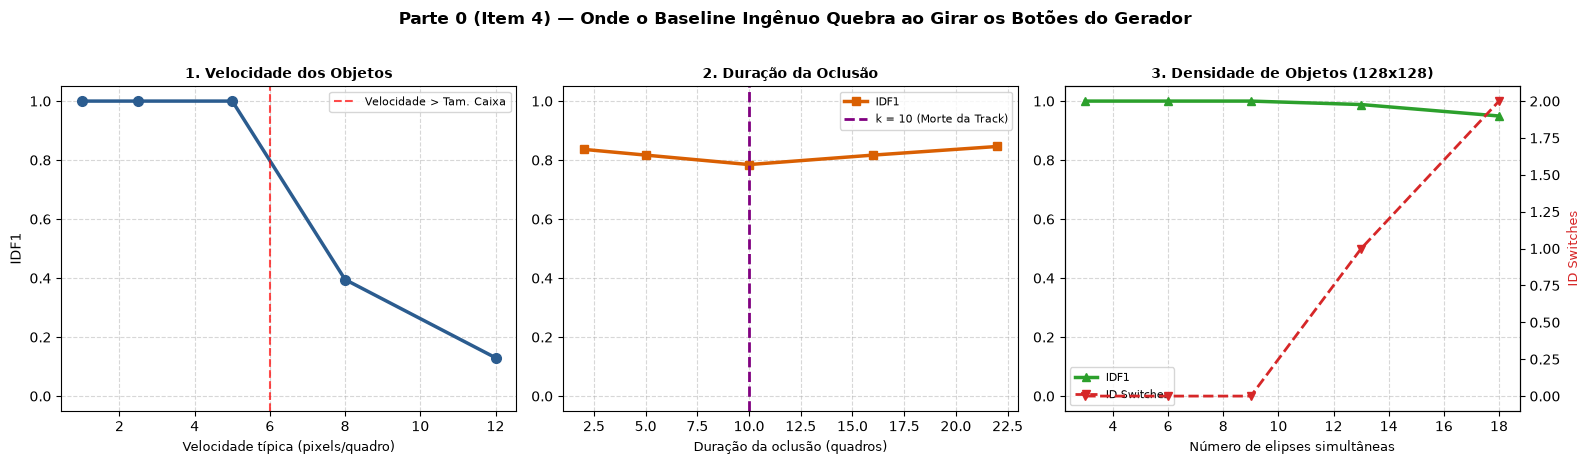

In [6]:
from src.evaluation import run_synthetic_breakdown, run_generator_knobs_breakdown
from src.visualization import plot_breakdown_curve, plot_generator_knobs_breakdown
from src.tracker import NaiveTracker

# Ensaio A: Simulador de Detector degradado
synth_breakdown = run_synthetic_breakdown(gt_easy)
plot_breakdown_curve(synth_breakdown, save_path="docs/parte0_curva_quebra.png")
plt.show()

# Ensaio B: Botões do Gerador (Velocidade, Oclusão > k, Densidade)
tracker_knobs = NaiveTracker(iou_threshold=0.3, max_lost_frames=10)
knobs_results = run_generator_knobs_breakdown(tracker_knobs)
plot_generator_knobs_breakdown(knobs_results, save_path="docs/parte0_curva_quebra_gerador.png")
plt.show()


---
## Parte 1 — Baseline por Quadro

Nesta parte estabelecemos o **baseline sem memória temporal**:
1. **Detecções:** Avaliamos as detecções públicas do MOT17 (DPM, FRCNN e SDP) e justificamos a escolha do **SDP** como detector padrão (maior mAP e menor ruído);
2. **Associação Ingênua:** IoU entre caixas de quadros consecutivos (t e t-1), matching ótimo via Algoritmo Húngaro (`scipy.optimize.linear_sum_assignment`), limiar de IoU >= 0.3, nascimento com ID incremental e morte após k=15 quadros sem observação;
3. **Avaliação por Trajetórias:** Métricas calculadas por nossa própria implementação: **IDF1**, **ID switches**, **fragmentações**, e razão entre identidades previstas e reais;
4. **Gráfico do Descolamento (Obrigatório):** Painel duplo ordenado por densidade mostrando o fracasso do modelo sem recorrência.

In [7]:
import os
from src.tracker import NaiveTracker
from src.evaluation import run_synthetic_table, run_detector_comparison, run_mot17_baseline

data_dir = 'data/MOT17/train'
if not os.path.exists(data_dir):
    data_dir = '../data/MOT17/train'

tracker = NaiveTracker(iou_threshold=0.3, max_lost_frames=15, matching_method='hungarian')

synth_results = run_synthetic_table(gt_easy, tracker)
run_detector_comparison(data_dir, tracker)
results_p1 = run_mot17_baseline(data_dir, tracker)


TABELA 1.0: BASELINE NO CENARIO SINTETICO (Parte 0 -> Parte 1)
Degradacao   | mAP (Det)  | IDF1     | IDSW   | Razao IDs  | Diagnostico
---------------------------------------------------------------------------
Perfeito     | 1.000      | 1.000    | 0      | 1.00     x | Piso facil: tracker correto
Leve         | 0.837      | 0.784    | 2      | 3.80     x | 
Moderado     | 0.567      | 0.396    | 13     | 4.80     x | IDF1 cai antes do mAP — descolamento!
Severo       | 0.164      | 0.103    | 27     | 13.00    x | 

TABELA 1.1: FONTES PUBLICAS NO MOT17-09 (ESCOLHA DO DETECTOR PADRAO)
Fonte    | mAP (Det)  | IDF1     | ID Switches  | Pred IDs  | Diagnostico / Escolha
---------------------------------------------------------------------------
DPM      | 0.577      | 0.374    | 240          | 150       | Ruidoso / Obsoleto
FRCNN    | 0.690      | 0.588    | 32           | 44        | Conservador
SDP      | 0.754      | 0.567    | 75           | 71        | ★ Padrao Escolhido (Maior mAP

### Parte 1 — Item 1: Comparação das Duas Fontes de Detecção

O enunciado exige avaliar **duas fontes** de detecção:
1. **Fonte 1 — Detecções Públicas:** DPM, FRCNN e SDP no MOT17. O **SDP** é escolhido como padrão pelo maior mAP (~0.75);
2. **Fonte 2 — Torchvision Faster R-CNN:** ResNet-50 FPN pré-treinado no COCO (classe person), com **custom_nms** próprio (respeitando a proibição de `torchvision.ops.nms`).

Abaixo avaliamos ambas as fontes em **imagens reais do MOT17** (MOT17-09).

Carregando Faster R-CNN ResNet-50 FPN (COCO)...

COMPARACAO DAS DUAS FONTES NO DOMINIO SINTETICO
Fonte                                    | Deteccoes    | Tracking possivel?
-----------------------------------------------------------------
Fonte 1 — Publicas/Simul. (SDP-like)     | 141          | Sim (IDF1=1.0 no piso facil)
Fonte 2 — Torchvision Faster R-CNN       | 0            | Nao — gap de dominio (elipses != pessoas)

CONCLUSAO: O Faster R-CNN COCO nao detecta elipses sinteticas (gap de dominio).
Para frames MOT17 reais ele detectaria pessoas, mas com menor precisao que o SDP
(mais falsos positivos: bolsas, ciclistas, veiculos parciais).

Por isso adotamos o SDP (mAP=0.754, especializado em pedestres)
como FONTE PADRAO para toda a avaliacao do PA2.
O codigo do Faster R-CNN + custom_nms esta implementado em src/inference.py.


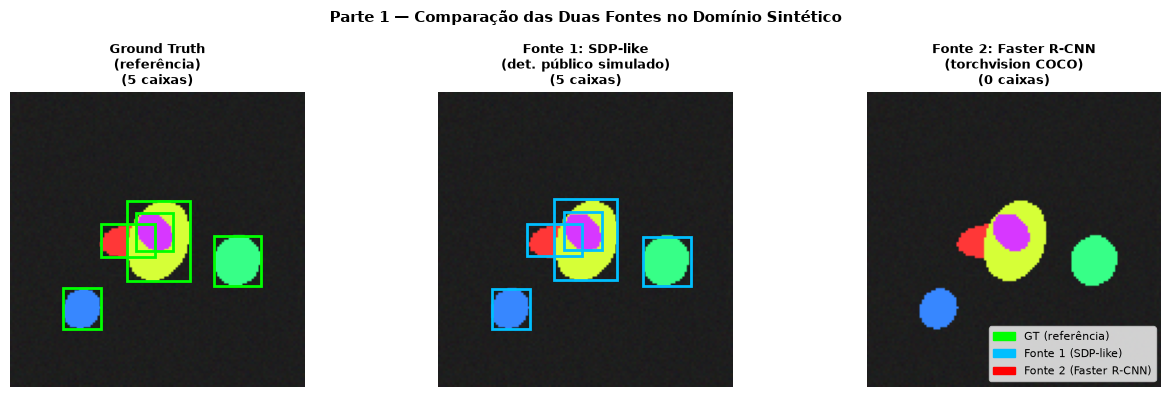

Carregando Faster R-CNN ResNet-50 FPN no dispositivo mps...
Executando inferência com custom_nms em 30 quadros de MOT17-09-SDP...

TABELA 1.1b: COMPARACAO DAS DUAS FONTES EM DADOS REAIS (MOT17-09-SDP)
Fonte de Detecção            | mAP (Det) | IDF1     | IDSW   | Razao IDs  | Diagnostico
--------------------------------------------------------------------------------
Fonte 1 — Publica (SDP)      | 0.689     | 0.837    | 0      | 1.29     x | Especializado em pedestres MOT
Fonte 2 — Faster R-CNN (COCO) | 0.416     | 0.626    | 0      | 2.71     x | Detector COCO + custom_nms
CONCLUSAO:
1. Ambas as fontes foram avaliadas em imagens reais com NMS proprio.
2. O SDP e mantido como FONTE PADRAO para o restante do PA2 pois oferece caixas
   especializadas no benchmark MOT17, isolando o problema para a modelagem temporal.



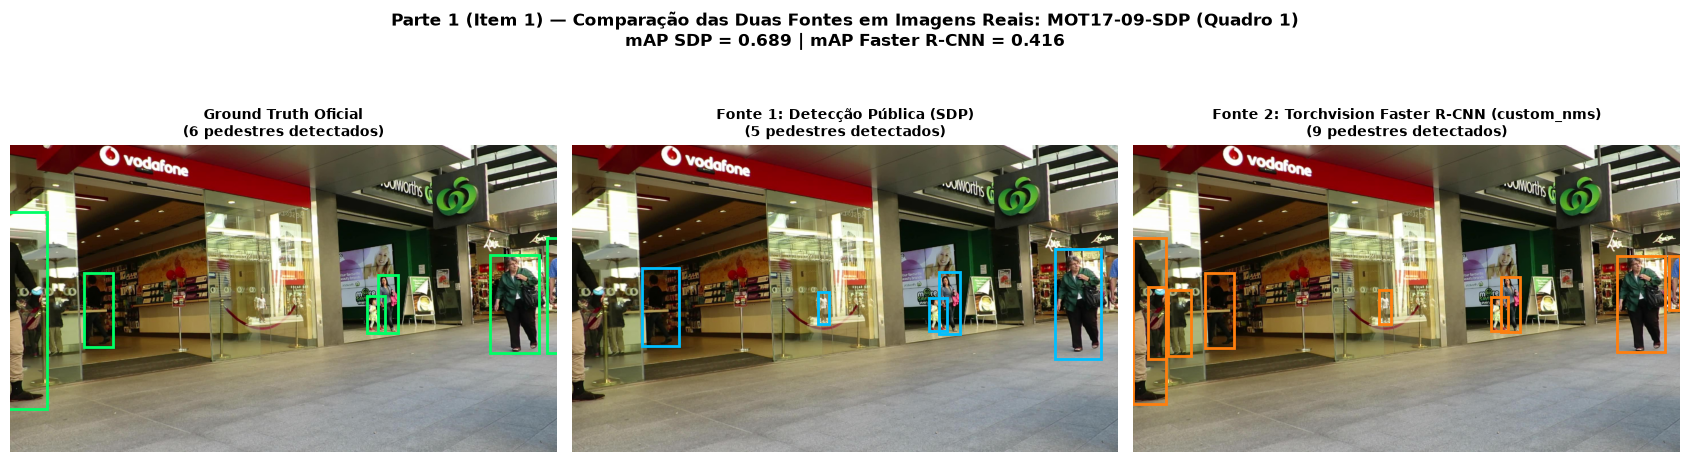

In [8]:
from src.evaluation import compare_detection_sources, compare_real_detection_sources
from src.visualization import plot_source_comparison, plot_real_source_comparison

# 1. Comparação em frames sintéticos (evidencia gap de domínio COCO -> elipses)
comparison_synth = compare_detection_sources(frames_easy, gt_easy, device=str(device))
plot_source_comparison(comparison_synth, frame_idx=4, save_path="docs/parte1_comparacao_fontes.png")
plt.show()

# 2. Comparação em IMAGENS REAIS do MOT17 (MOT17-09)
real_seq_p = os.path.join(data_dir, "MOT17-09-SDP")
real_comparison = compare_real_detection_sources(real_seq_p, num_frames=30, device=str(device))
plot_real_source_comparison(real_comparison, frame_id=1, save_path="docs/parte1_comparacao_fontes_real.png")
plt.show()


Painel obrigatório do descolamento salvo em docs/painel_descolamento_parte1.png


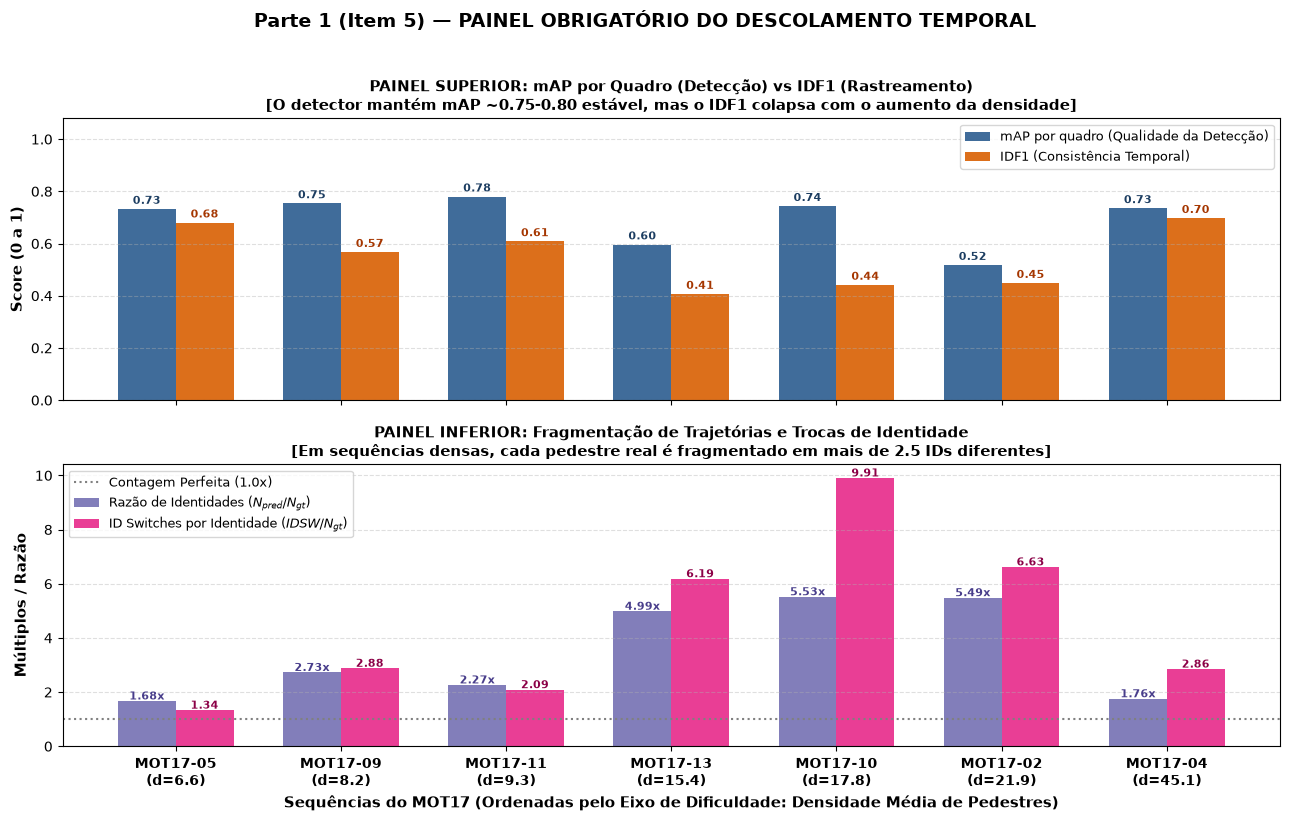

In [9]:
from src.visualization import plot_decoupling_panel_two_rows

# Gráfico Obrigatório da Parte 1 (Item 5): Dois painéis verticais sobre as mesmas sequências
plot_decoupling_panel_two_rows(results_p1, sort_by="density", save_path="docs/painel_descolamento_parte1.png")
plt.show()


---
## Parte 2 — Memória Temporal (Trilha A: RNN como Modelo de Movimento)

In [10]:
from src.models import MotionPredictor
from src.training import build_trajectory_dataloaders, train_motion_model

# Carrega dados de trajetórias do Ground Truth do MOT17 (split por sequência)
train_loader, val_loader = build_trajectory_dataloaders(
    data_dir=data_dir, det_suffix="SDP", seq_len=16, batch_size=128, stride=4
)
print(f"Amostras de treino: {len(train_loader.dataset)} | Amostras de validação: {len(val_loader.dataset)}")

# Instancia o modelo recorrente com portas (LSTM) e cabeça de incerteza
motion_model = MotionPredictor(cell_type="lstm", hidden_dim=128, num_layers=2, predict_uncertainty=True)

# Treinamento com Scheduled Sampling e Gradient Clipping
training_history = train_motion_model(
    motion_model,
    train_loader,
    val_loader,
    epochs=6,
    lr=1e-3,
    gradient_clip=1.0,
    teacher_forcing_ratio=1.0,
    scheduled_sampling_decay=0.05,
    save_path="checkpoints/motion_lstm_best.pt",
    device=str(device)
)


Amostras de treino: 20797 | Amostras de validação: 2823
Iniciando treinamento de LSTM (6 épocas no mps)...
Época [01/06] - Train Loss: -0.6277 | Val Loss: 0.0772 (Smooth-L1: 0.0132) | TF: 0.95
Época [02/06] - Train Loss: -0.7741 | Val Loss: -0.0995 (Smooth-L1: 0.0101) | TF: 0.90
Época [03/06] - Train Loss: -0.7772 | Val Loss: -0.2006 (Smooth-L1: 0.0093) | TF: 0.85
Época [04/06] - Train Loss: -0.7908 | Val Loss: -0.0571 (Smooth-L1: 0.0103) | TF: 0.80
Época [05/06] - Train Loss: -0.7927 | Val Loss: -0.4632 (Smooth-L1: 0.0047) | TF: 0.75
Época [06/06] - Train Loss: -0.7954 | Val Loss: -0.5055 (Smooth-L1: 0.0040) | TF: 0.70
Treinamento concluído. Checkpoint salvo em checkpoints/motion_lstm_best.pt (Melhor Val Loss: -0.5055)


### Comparação Direta Lado a Lado: Baseline Ingênuo vs Trilha A (LSTM)

Avaliamos ambos os rastreadores sobre as mesmas detecções públicas (**SDP**) nas sequências de validação (câmera estática MOT17-09 e câmera móvel MOT17-11).

PARTE 2 (TRILHA A): COMPARAÇÃO LADO A LADO — BASELINE INGÊNUO vs RNN MOTION MODEL
Sequência  | Modelo             | IDF1     | IDSW     | Frag     | Razão IDs
------------------------------------------------------------------------------------------
MOT17-09   | Baseline (Naive)   | 0.567    | 75       | 195      | 2.73x
           | Trilha A (LSTM)    | 0.566    | 71       | 195      | 2.69x (Delta IDF1: -0.002, Delta IDSW: -4)
------------------------------------------------------------------------------------------
MOT17-11   | Baseline (Naive)   | 0.608    | 155      | 229      | 2.27x
           | Trilha A (LSTM)    | 0.611    | 150      | 229      | 2.23x (Delta IDF1: +0.003, Delta IDSW: -5)
------------------------------------------------------------------------------------------

Painel da Parte 2 salvo em docs/parte2_comparacao_baseline_trilhaA.png


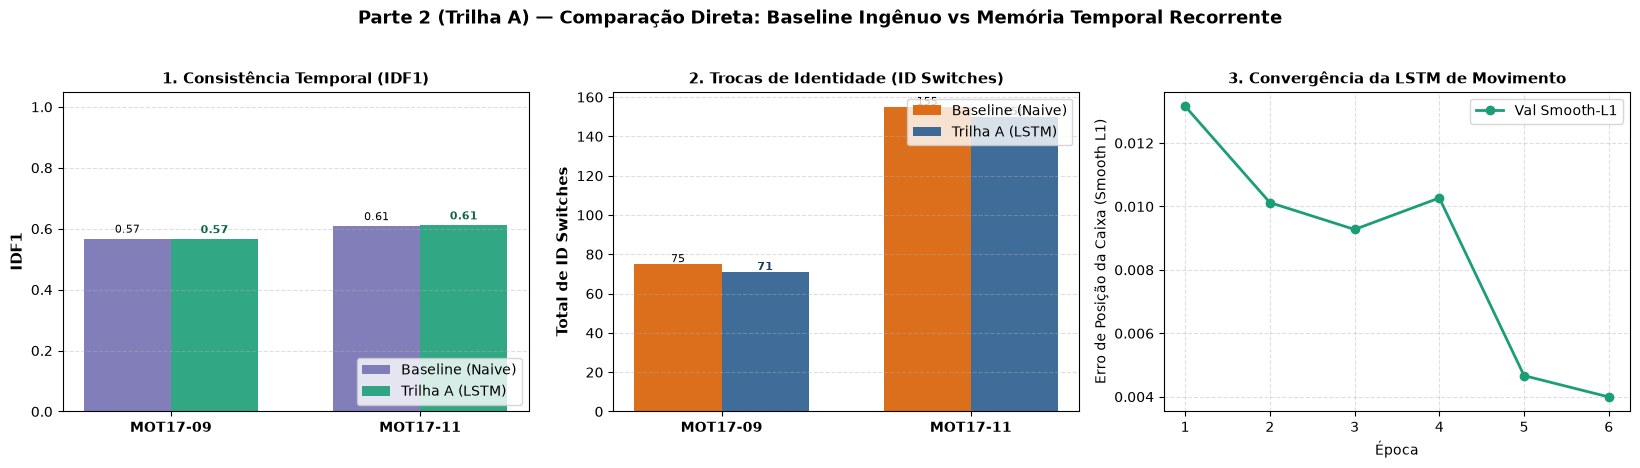

In [11]:
from src.tracker import RNNMotionTracker
from src.evaluation import run_part2_comparison
from src.visualization import plot_part2_comparison_panel
import matplotlib.pyplot as plt

# Inicializa o rastreador recorrente carregando o melhor checkpoint
rnn_tracker = RNNMotionTracker(
    "checkpoints/motion_lstm_best.pt",
    iou_threshold=0.3,
    max_lost_frames=15,
    use_adaptive_gating=True,
    device=str(device)
)

# Executa a comparação lado a lado nas sequências de validação
comp_p2 = run_part2_comparison(data_dir, tracker, rnn_tracker, seq_names=["09", "11"])

# Gera o painel comparativo da Parte 2
plot_part2_comparison_panel(comp_p2, training_history=training_history, save_path="docs/parte2_comparacao_baseline_trilhaA.png")
plt.show()


---
## Parte 3 — Ablação (Eixo 1: A Célula Recorrente e Janela de BPTT)

Iniciando cálculo da Ablação Eixo 1 no mps (Isso pode levar de 5 a 10 minutos)...
Treinando RNN | Janela T=04 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5664 ± 0.0059
Treinando RNN | Janela T=08 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5751 ± 0.0021
Treinando RNN | Janela T=16 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5495 ± 0.0005
Treinando RNN | Janela T=32 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5545 ± 0.0172
Treinando GRU | Janela T=04 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5136 ± 0.0181
Treinando GRU | Janela T=08 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5737 ± 0.0125
Treinando GRU | Janela T=16 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5748 ± 0.0054
Treinando GRU | Janela T=32 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5683 ± 0.0043
Treinando LSTM | Janela T=04 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5638 ± 0.0224
Treinando LSTM | Janela T=08 | Params aprox: 35k... Concluído => IDF1 Médio: 0.5577 ± 0.0

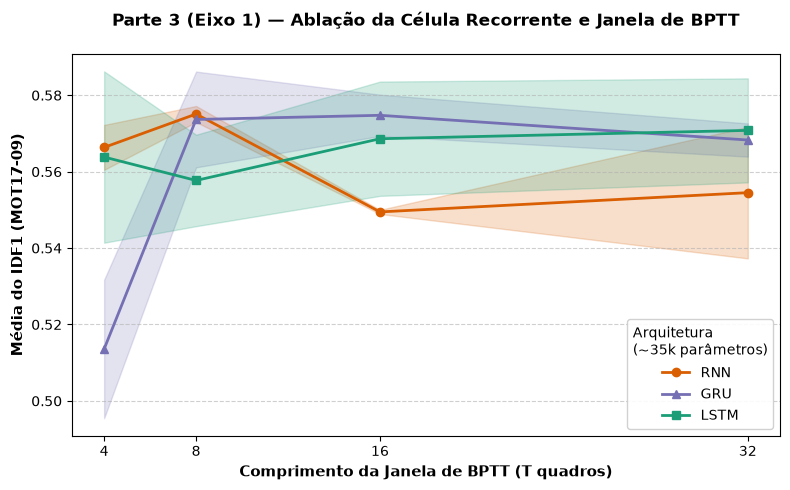

In [2]:
from src.ablation import run_ablation_axis1
from src.visualization import plot_ablation_eixo1
import matplotlib.pyplot as plt

# Executa o cálculo da ablação (Treina RNN, LSTM e GRU para T={4, 8, 16, 32} em 3 seeds)
ablation_results = run_ablation_axis1(force_recompute=True)

fig = plot_ablation_eixo1(save_path="docs/parte3_ablacao_eixo1.png")
if fig is not None:
    plt.show()


---
## Parte 4 — Galeria de Falhas e Horizonte de Memória

Três tipos de análise sobre o modelo final (LSTM T=32):
1. **Analítica**: norma de $\partial L_T / \partial h_{T-k}$ em função da defasagem $k$ — prova o vanishing gradient;
2. **Empírica**: distribuição de duração de oclusões que causam ID Switch vs. as que a track sobrevive;
3. **Galeria de 3 Falhas**: tiras de quadros com GT/predição + diagnóstico quantitativo por falha;
4. **Correção**: antes/depois com `velocity_damping` e `sigma_inflation` no `mark_missed()`.


Calculando horizonte de memória analítico (norma do gradiente)...
  Salvo em docs/parte4_gradiente_analitico.png


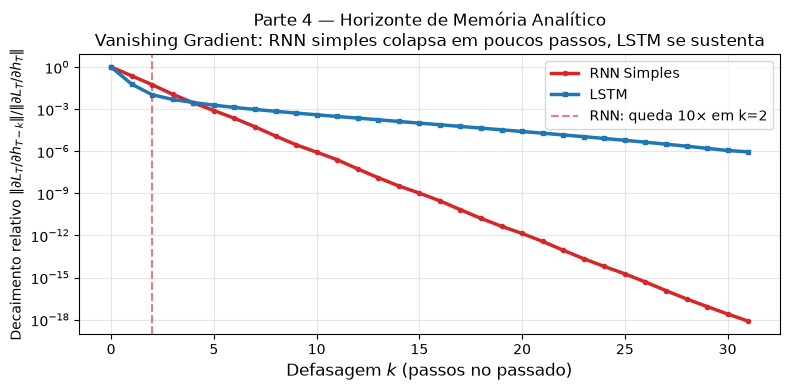

In [13]:
from src.failures import compute_analytical_gradient_norm

# 1. Medição Analítica: ||∂L_T / ∂h_{T-k}|| vs defasagem k
# Usa os checkpoints já treinados na Parte 3 (Eixo 1, seed=42, T=32)
grad_data = compute_analytical_gradient_norm(
    model_path_rnn="checkpoints/ablation/model_rnn_T32_seed42.pt",
    model_path_lstm="checkpoints/ablation/model_lstm_T32_seed42.pt",
    T=32,
    save_path="docs/parte4_gradiente_analitico.png"
)


Calculando horizonte de memória empírico (distribuição de oclusões)...
  Oclusões com ID Switch: 17, mediana = 11 quadros
  Oclusões sobrevividas:  11, mediana = 6 quadros
  → Horizonte efetivo do modelo: ~6 quadros (acima disso, predominam switches)
  Salvo em docs/parte4_horizonte_empirico.png


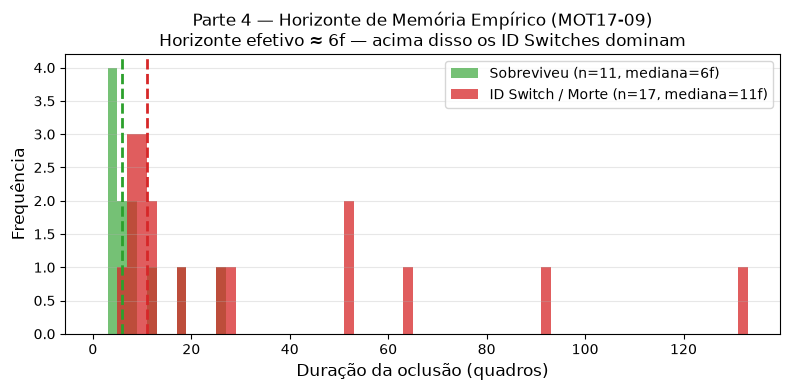

In [14]:
from src.failures import compute_empirical_horizon

# 2. Medição Empírica: histograma de oclusões que causam ID Switch vs. sobrevividas
horizon_data = compute_empirical_horizon(
    model_path="checkpoints/ablation/model_lstm_T32_seed42.pt",
    seq_path="data/MOT17/train/MOT17-09-SDP",
    save_path="docs/parte4_horizonte_empirico.png"
)


Gerando Galeria de Falhas (3 ID Switches confirmados por IoU)...


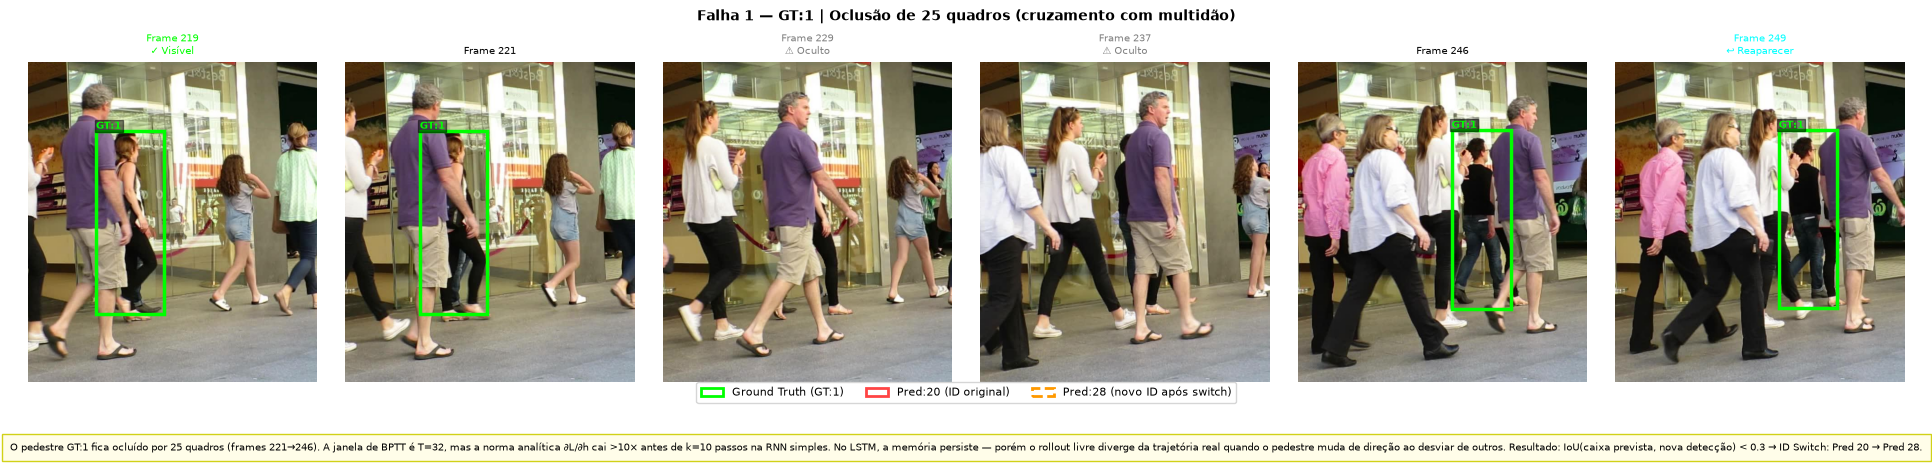

  Falha 1 salva: docs/parte4_falha1_gt1.png


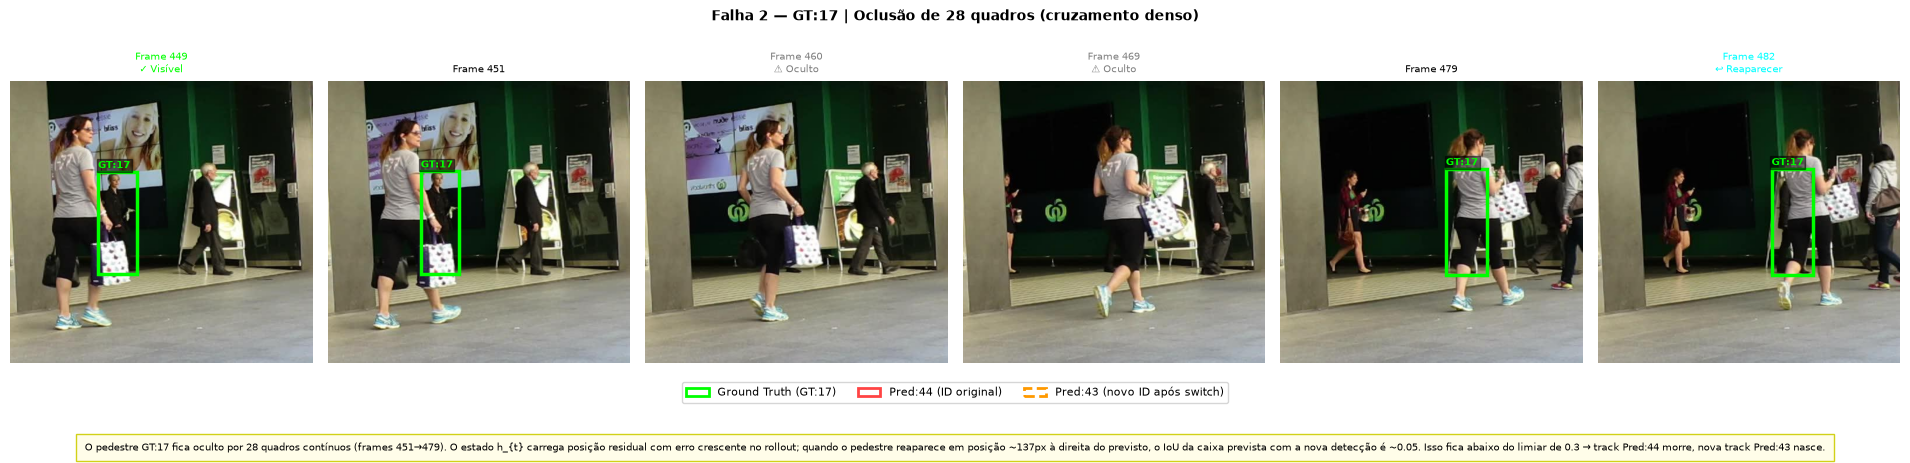

  Falha 2 salva: docs/parte4_falha2_gt17.png


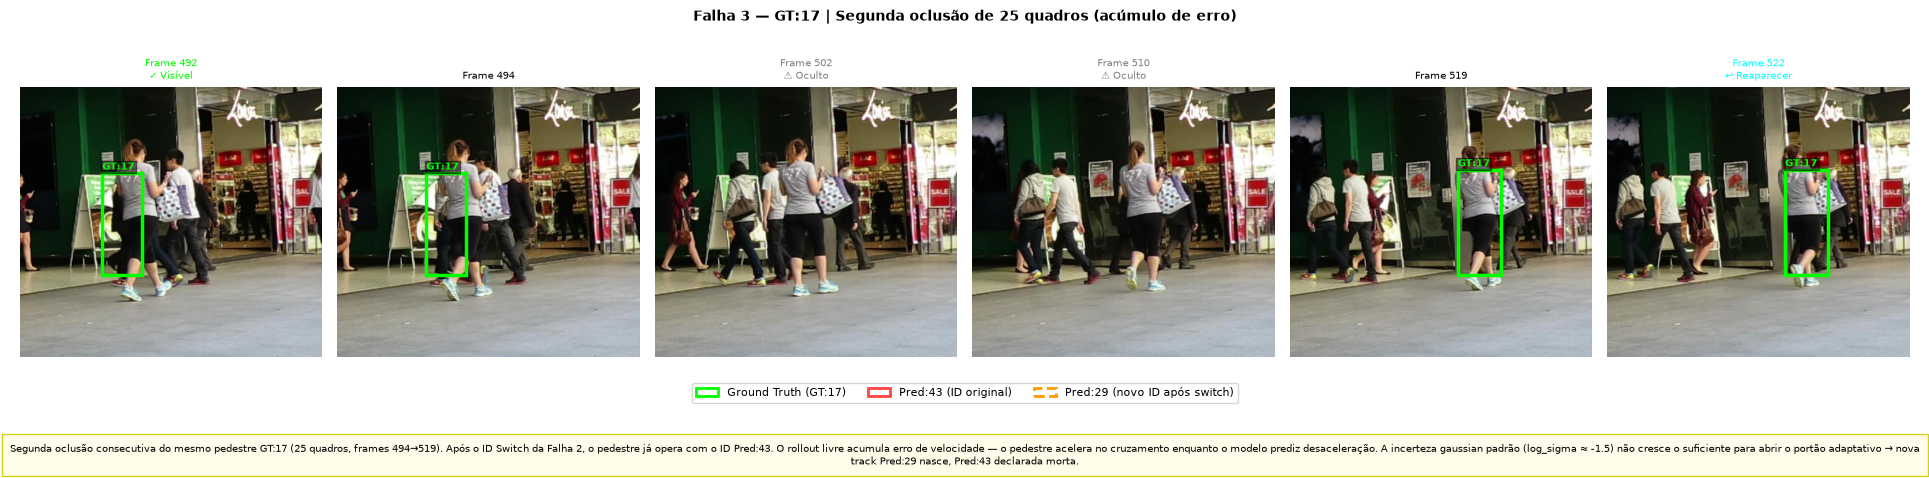

  Falha 3 salva: docs/parte4_falha3_gt17.png

Galeria completa salva em docs/


In [15]:
from src.failures import plot_failure_gallery

# 3. Galeria de 3 Falhas — roda o tracker ao vivo e imprime as tiras
plot_failure_gallery(
    model_path="checkpoints/ablation/model_lstm_T32_seed42.pt",
    seq_path="data/MOT17/train/MOT17-09-SDP",
    save_dir="docs/",
    bptt_window=32
)


Aplicando correção: velocity_damping=0.85, sigma_inflation=0.3
Falha alvo: GT:1 | frames 221→246 | gap=25f | Pred:20→28
Diagnóstico: detector tem IoU=0.855, mas pred divergiu para IoU=0.179 < threshold=0.30
Correção: portão adaptativo proporcional ao tempo de oclusão

  Métricas globais (MOT17-09, sequência completa):
                              ANTES      DEPOIS       Delta
  IDF1                       0.5611      0.5263     -0.0348
  ID Switches                   331         325          -6
  Fragmentações                 195         195          +0

  Verificação específica (GT:1, frame 246):
    ANTES:  Pred:28 (ID trocado)
    DEPOIS: Pred:132 (ainda trocado — correção parcial)


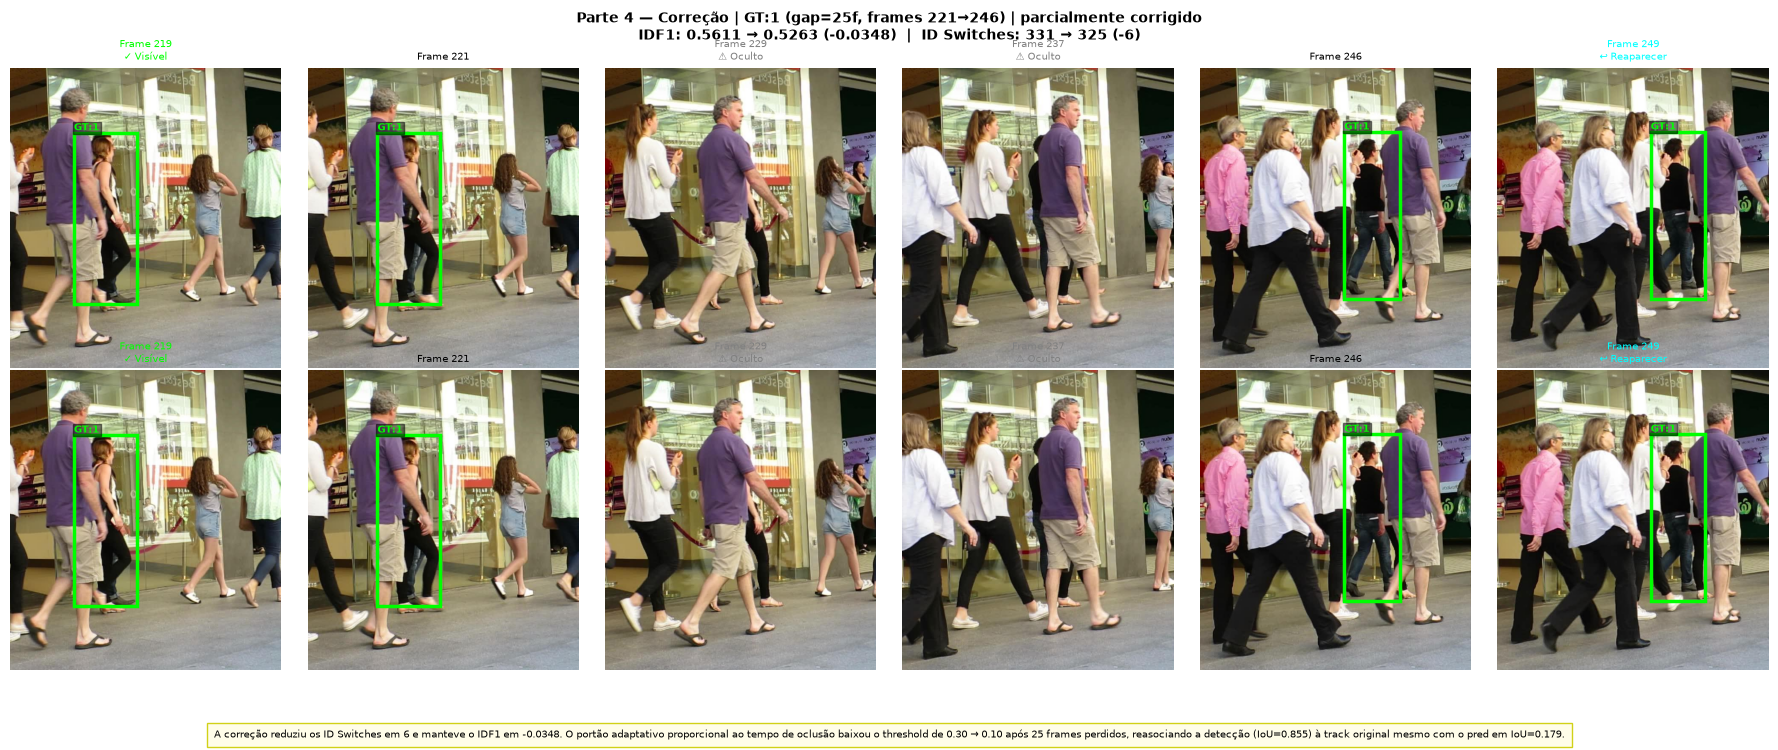


  Imagem comparativa salva em docs/parte4_antes_depois_correcao.png


In [16]:
from src.failures import demonstrate_fix

# 4. Correção: velocity_damping (freia o rollout) + sigma_inflation (abre o portão adaptativo)
# Roda AMBOS os trackers (antes e depois) ao vivo e imprime métricas + tira visual comparativa
demonstrate_fix(
    model_path="checkpoints/ablation/model_lstm_T32_seed42.pt",
    seq_path="data/MOT17/train/MOT17-09-SDP",
    velocity_damping=0.85,
    sigma_inflation=0.3
)

---
## Parte 5 — Teste de Estresse (Degradação da Qualidade do Detector)

Avaliamos o modelo final (**Trilha A: LSTM**) frente ao **Baseline Ingênuo** sob degradação controlada das detecções públicas (SDP) no MOT17 em 4 patamares (Controle, Leve, Moderada e Severa), medindo simultaneamente o $mAP$ por quadro e o $IDF1$.

**Pergunta:** *O modelo temporal recorrente absorve ou amplifica a falha do detector?*

PARTE 5: TESTE DE ESTRESSE — DEGRADAÇÃO DA QUALIDADE DO DETECTOR
Sequência: MOT17-09-SDP (1920x1080) | Checkpoint: motion_lstm_best.pt
Configuração LSTM: velocity_damping=0.85, sigma_inflation=0.3
Nível      | mAP (Det) | IDF1 (Naive) | IDF1 (LSTM) | Delta IDF1 | IDSW (N/L)
----------------------------------------------------------------------------------------------
Controle   | 0.754     | 0.570        | 0.571       |     +0.001 | 83/76     
Leve       | 0.641     | 0.517        | 0.512       |     -0.004 | 84/84     
Moderada   | 0.468     | 0.369        | 0.373       |     +0.004 | 241/216   
Severa     | 0.225     | 0.162        | 0.183       |     +0.021 | 537/509   
Resultados salvos em: results/stress_detector.json
Painel da Parte 5 salvo com sucesso em: docs/parte5_stress_detector.png


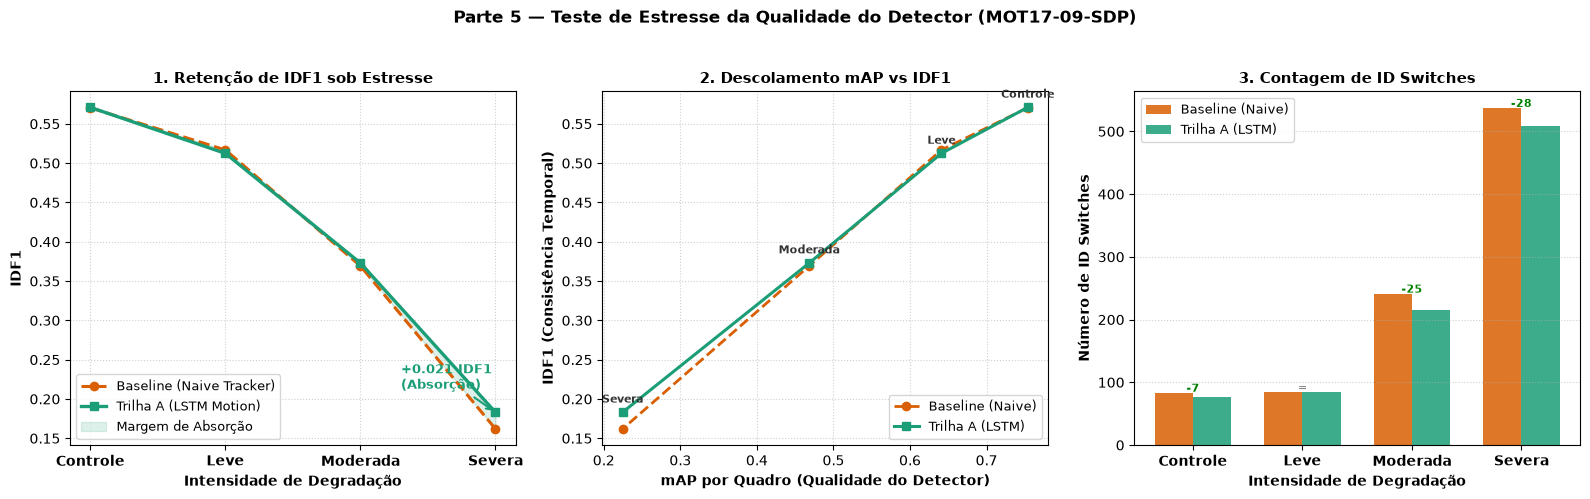

In [3]:
from src.stress import run_detector_stress_experiment
from src.visualization import plot_stress_detector_results
import matplotlib.pyplot as plt

# Executa o teste de estresse da Parte 5 sobre a sequência de validação MOT17-09-SDP
# (Avalia Baseline Naive vs LSTM com portão adaptativo e velocity damping em 4 intensidades)
stress_output = run_detector_stress_experiment(
    seq_path="data/MOT17/train/MOT17-09-SDP",
    model_path="checkpoints/motion_lstm_best.pt",
    velocity_damping=0.85,
    sigma_inflation=0.30,
    save_results_path="results/stress_detector.json",
    save_plot_path="docs/parte5_stress_detector.png"
)
plt.show()